<a href="https://colab.research.google.com/github/AllenInstitute/EducationAndEngagement/blob/main/NeuroCodingWorkshop/Solutions/04_Pandas_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas

<img src="https://pandas.pydata.org/static/img/pandas.svg" width="200">

## Learning Objectives

* Create & manipulate Pandas DataFrames
* Load data file(s) into a Pandas DataFrame
* Index and subset Pandas DataFrames
* Generate descriptive statistics for data in Pandas DataFrames
----


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

**<code>[pandas](https://pandas.pydata.org/)</code>** is a library with high-level data structures and manipulation tools:

**DataFrame Object**
    
A Pandas DataFrame is a two-dimensional size-mutable, potentially heterogeneous tabular data structure that holds ***relational data***.

Data is aligned in a tabular fashion with labeled rows and columns like a spreadsheet or SQL table, or a dict of Series objects. Essentially, a Pandas DataFrame consists of three components, the data, rows, and columns.

Key takeaways:
* Represents a tabular, spreadsheet-like data structure
* Ordered collection of columns
* Each column can be a different value type (numeric, string, boolean, etc.)
* Holds relational data

<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/dataframe_example.png">
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Relational Data

Pandas dataframes/tables typically contain relational data. Relational data is data that captures associations or relationships between data points. This is often expressed as a table with columns indicating the quantities related. For example, "First Names" are associated with "Last Names".
    

This is a table with two columns, one column for First Name and one column for Last Name. For the pedantic, a "relation" is a table with no duplicate entries.

<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_relational_df.png" width='250'>
    
This is a table with two columns, one column for First Name and one column for Last Name.


For the pedantic, a "relation" is a table with no duplicate entries.  We might, for example, have two John Smiths.  We can try to eliminate this collision problem by introducing an **Index**.


<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_student_df_with_index.png" width='300'>  

    
**A brief note on row vs index:**
In this notebook and lecture we will use the terms row number and index. For many contexts these terms are interchangable, however due to pandas nomenclature around different ways of slicing and dicing data, we will have distinct meanings for these

**row number:** the number of the row starting with row 0 <br>
**index:** label given to a specific row
     
<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_relation_df_generic.png" width='250'>       

In the above table we have added an "Index".  The DataFrame object in Python is a representation of a table with these components.  It is composed of rows, each with an index, and labeled columns.
    
<br>

In a general DataFrame, we might have many different relations captured in the same table.  For example, a DataFrame with student data from a school might look something like this:
    
<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_relational_student_df.png" width='500'>

<br>

#### Data Representation

When thinking about data analysis, note that the above table already gives us something to think about regarding how choices of data representation affect conclusions.  
* What if someone only has one name?  
* What if they have a name that isn't easily represented as "First name/Last name"?  
* What if they come from a culture that keeps track of multiple names?  

Note there is a Gender column.  What if the person who constructed this data had created this column as `isFemale`?  

When interacting with tables and DataFrames, it is important to keep these issues in mind.  Structural choices about data can and will affect conclusions.  Whenever you make a DataFrame or use one someone else has constructed for you, you are making or dealing with these kinds of choices.
    
There are standard operations related to questions you might have about the students in the above DataFrame.
<ul>
    <li> Which students took Physics?  </li>
    <li> Which students got an A in any course?  Which Students from the University of Washington got an A or B in either Physics or History? </li>
    </ul>

The DataFrame object has operations that allow these kinds of questions to be answered in a computationally efficient manner. These are covered in this tutorial.
    
</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
### Many different relations

If we only needed to subselect from one table, we wouldn't really need something like `pandas` and its DataFrame (though it is helpful for this!).  The real power of the DataFrame object appears when we have multiple relations, i.e. multiple DataFrames and we wish to combine them in some way.

For example we might have DataFrames that represent student Grades, or Professors, or Schools.

<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_grade_df.png" width='200'>

    
or a DataFrame with Courses offered by Departments in different schools:

<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_departments_df.png" width='500'>

    
or a DataFrame of Professors and the Courses they teach
    
<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_professors.png" width='500'>
    
   

The main purpose of `pandas` and the DataFrame object is to allow us to ask questions across multiple sets of relations.  

    
<ul>
    <li>What is the average score of students of course Y from professor X (who may have taught at different institutions….)?</li>
    <li>What is the average number of students at school X from State Y?</li>
    <li>What is the distribution of grades from students in Biology whose home town is Y?</li>
</ul>
    



DataFrames have powerful tools like `merge` to combine information from multiple DataFrames that allow you to ask these kinds of questions quickly and easily.
    
Let's get started!  
    
</div>

<a id='why_use_pandas'></a>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Why Use Pandas
    
**Annotated Data is Powerful!**

Because pandas combines data labels with values it facilitites easy:
* Dataset exploration
* Dataset visualization
* Basic statistical analysis    

<br/>

**Data Manipulation is Easy!**

Pandas takes the functionality of slicing & dicing data and layers in many other helpful features that help with:
* Cleaning data
    * Column headers are descriptive not numerical
    * Columns hold single variables
    * Variables are stored in either rows or columns, not both
    * Handling missing or invalid values
* Data wrangling
    * Getting the data into a structure that facilitates your analysis
* Easily loading and saving data
    * Load many formats of data and save in many formats


<br/>
    
**High Level Data Manipulation**

Pandas supports vectorized mathematical operations which optimizes computation performance and execution speed. Additionally the 2D labeled tabular structure of a pandas DataFrame allows other high level manipulations such as:
* Data grouping aggregation
* Table manipulations (transforming rows to columns and/or columns to rows)
* Merging or joinng multiple DataFrames/tables</div>


----
<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    

#### Documentation & Resources
    
This introduction will only just scratch the surface of Pandas functionality. For more information, check out the [full documentation](https://pandas.pydata.org/docs/reference/index.html)
    
This [cheat-sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) is also highly recommended to print out and keep handy as a resource.
<p>Or check out the <a href="http://pandas.pydata.org/pandas-docs/stable/10min.html">'10 minutes to Pandas'</a> tutorial here (note: title may mischaracterize time investment).</div>

---


## Import Packages


<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">

**Library imports**    
Here we'll load in the libraries we'll use to shape and explore the data</div>


In [1]:
import os
import numpy as np

In [2]:
# import `pandas` and give it a short name `pd` since we will type it frequently
import pandas as pd

<a id='dataload'></a>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Load dataset

Our first step is loading in the data from a file

Pandas has great [tools for automatically interpretting data from many sources](https://pandas.pydata.org/docs/reference/io.html)
    
* [pd.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
* [pd.read_feather](https://pandas.pydata.org/docs/reference/api/pandas.read_feather.html)    
* [pd.read_excel](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html)
* [pd.read_pickle](https://pandas.pydata.org/docs/reference/api/pandas.read_pickle.html)
* [pd.read_json](https://pandas.pydata.org/docs/reference/api/pandas.read_json.html)
    
We will use `pd.read_feather`</div>


In [3]:
# Create directory structure if it doesn't exist
os.makedirs('support_files/datasets', exist_ok=True)

# Download from GitHub
!wget -O support_files/datasets/messy_superstore_data.feather https://github.com/AllenInstitute/EducationAndEngagement/raw/main/NeuroCodingWorkshop/support_files/datasets/messy_superstore_data.feather

# Load file
filepath = os.path.join('support_files', 'datasets', 'messy_superstore_data.feather')
df = pd.read_feather(filepath)

# Set the index
df.set_index('Row ID', inplace=True)

--2026-07-24 16:20:25--  https://github.com/AllenInstitute/EducationAndEngagement/raw/main/NeuroCodingWorkshop/support_files/datasets/messy_superstore_data.feather
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/datasets/messy_superstore_data.feather [following]
--2026-07-24 16:20:25--  https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/datasets/messy_superstore_data.feather
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2891970 (2.8M) [application/octet-strea

----
<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Explore the dataset

### Basic data exploration

* <a href='#df'>view dataframe "preview"</a>
* <a href='#.head()'> view rows from beginning or end of dataframe (`df.head`, `df.tail`)</a>
* <a href='#shape'>get dataframe shape and length (`len`, `np.shape`)</a>   
* <a href='#.columns'>list all columns (`.columns`)</a>
* <a href='#single_col'>show single column data</a>
* <a href='#dtypes'>get column data types (`.dtypes`)</a>
* <a href='#unique'>get unique entries (`.unique()`)</a>
    
### Basic data visualization
* <a href='#plot'>plotting with pandas (`.plot`)</a>

### Descriptive statistics
* <a href='#describe'> get table level descriptive statistics</a>
* <a href='#other'>other built in summary functions</a>
  

</div>

---


<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="df"></a>

#### View the DataFrame

Simply calling the DataFrame (`df` or whatever you've named the DataFrame) gives a preview view of the DataFrame/table
* shows the first 5 and last 5 rows of data
* shows the first 10 and last 10 columns of data
</div>


In [4]:
# view the df

df

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
IN-2014-23218,IN-2014-75456,Consumer,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Door Stop, Erganomic",FUR-FU-10004064,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Globex Corp, Hudsucker Indust..."
IN-2014-24599,IN-2014-29767,Home Office,FURNITURE,NaN,BOOKCASES,"Ikea Library with Doors, Mobile",FUR-BO-10001255,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,731.820,NaN,NaN,NaN,Herat,Hirat,"[ACME Co, Buy n Large, Dunder Mifflin, Globex ..."
IN-2014-24597,IN-2014-29767,Home Office,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Door Stop, Erganomic",FUR-FU-10004064,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,169.680,NaN,NaN,NaN,Herat,Hirat,"[Dunder Mifflin, LexCorp, Olivander Crafts, Ro..."
IN-2014-27993,IN-2014-20415,Home Office,FURNITURE,NaN,BOOKCASES,"Bush Classic Bookcase, Pine",FUR-BO-10002204,Afghanistan,APAC,Central Asia,...,NaN,2070.15,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Olivander Crafts]"
IN-2014-28967,IN-2014-47337,Corporate,FURNITURE,NaN,CHAIRS,"Hon Rocking Chair, Red",FUR-CH-10003965,Afghanistan,APAC,Central Asia,...,914.34,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[ACME Co, Buy n Large, Dunder Mifflin, LexCorp..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZA-2014-49187,ZA-2014-9750,Corporate,TECHNOLOGY,NaN,ACCESSORIES,"Memorex Router, USB",TEC-MEM-10002202,Zambia,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,246.42,NaN,Ndola,Copperbelt,"[ACME Co, Royco Waystar, Umbrella Corporation]"
ZI-2014-42069,ZI-2014-7610,Corporate,TECHNOLOGY,NaN,MACHINES,"StarTech Phone, Red",TEC-STA-10000699,Zimbabwe,Africa,Africa,...,NaN,NaN,NaN,21.501,NaN,NaN,NaN,Bulawayo,Bulawayo,[Dunder Mifflin]
ZI-2014-43712,ZI-2014-5970,Home Office,TECHNOLOGY,NaN,ACCESSORIES,"Belkin Router, USB",TEC-BEL-10003985,Zimbabwe,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,77.688,Bulawayo,Bulawayo,"[ACME Co, Buy n Large, Hudsucker Industries]"


<a id='.head()'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name=".head()"></a>

#### View the first or last n rows

**[.head()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)**: shows the first n rows

**[.tail()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.tail.html)**: shows the last n rows

* <code>df.head()</code> and <code>df.tail()</code> shows 5 rows of data by default
* adding a number <code>df.head(n)</code> adjusts the number of rows shown</div>


In [5]:
# add a number to show the first `n` rows

df.head()

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
IN-2014-23218,IN-2014-75456,Consumer,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Door Stop, Erganomic",FUR-FU-10004064,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Globex Corp, Hudsucker Indust..."
IN-2014-24599,IN-2014-29767,Home Office,FURNITURE,NaN,BOOKCASES,"Ikea Library with Doors, Mobile",FUR-BO-10001255,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,731.82,NaN,NaN,NaN,Herat,Hirat,"[ACME Co, Buy n Large, Dunder Mifflin, Globex ..."
IN-2014-24597,IN-2014-29767,Home Office,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Door Stop, Erganomic",FUR-FU-10004064,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,169.68,NaN,NaN,NaN,Herat,Hirat,"[Dunder Mifflin, LexCorp, Olivander Crafts, Ro..."
IN-2014-27993,IN-2014-20415,Home Office,FURNITURE,NaN,BOOKCASES,"Bush Classic Bookcase, Pine",FUR-BO-10002204,Afghanistan,APAC,Central Asia,...,NaN,2070.15,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Olivander Crafts]"
IN-2014-28967,IN-2014-47337,Corporate,FURNITURE,NaN,CHAIRS,"Hon Rocking Chair, Red",FUR-CH-10003965,Afghanistan,APAC,Central Asia,...,914.34,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[ACME Co, Buy n Large, Dunder Mifflin, LexCorp..."


In [6]:
# add a number to show the last `n` rows

df.tail()

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
ZA-2014-49187,ZA-2014-9750,Corporate,TECHNOLOGY,NaN,ACCESSORIES,"Memorex Router, USB",TEC-MEM-10002202,Zambia,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,246.42,NaN,Ndola,Copperbelt,"[ACME Co, Royco Waystar, Umbrella Corporation]"
ZI-2014-42069,ZI-2014-7610,Corporate,TECHNOLOGY,NaN,MACHINES,"StarTech Phone, Red",TEC-STA-10000699,Zimbabwe,Africa,Africa,...,NaN,NaN,NaN,21.501,NaN,NaN,NaN,Bulawayo,Bulawayo,[Dunder Mifflin]
ZI-2014-43712,ZI-2014-5970,Home Office,TECHNOLOGY,NaN,ACCESSORIES,"Belkin Router, USB",TEC-BEL-10003985,Zimbabwe,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,77.688,Bulawayo,Bulawayo,"[ACME Co, Buy n Large, Hudsucker Industries]"
ZI-2014-48372,ZI-2014-9550,Consumer,TECHNOLOGY,NaN,MACHINES,"Konica Receipt Printer, Red",TEC-KON-10003116,Zimbabwe,Africa,Africa,...,71.64,NaN,NaN,NaN,NaN,NaN,NaN,Bulawayo,Bulawayo,"[ACME Co, Wayne Enterprises]"
ZI-2014-48014,ZI-2014-3570,Consumer,TECHNOLOGY,NaN,MACHINES,"Okidata Calculator, Red",TEC-OKI-10001433,Zimbabwe,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harare,Harare,"[Dunder Mifflin, Olivander Crafts, Royco Wayst..."


<a id='shape'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="shape"></a>

#### Get the shape and length of the DataFrame
pandas is built off of numpy, so many familiar functions/methods work with DataFrames    

* **[numpys shape function](https://numpy.org/doc/stable/reference/generated/numpy.shape.html)** can give the dimensions of a DataFrame
    * <code>df.shape</code> - returns (rows, columns)
* **[len()](https://docs.python.org/3/library/functions.html#len)** - the built in python function will return the number of rows in a DataFrame
    * <code>len(df)</code></div>


In [7]:
# code goes here to find the shape of the df

df.shape

(17531, 34)

In [8]:
# code goes here to find the length of the df

len(df)

17531

<a id='.columns'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name=".columns"></a>

#### List Columns

**[.columns](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)** provides a list of the column labels for a DataFrame
    
<code>df.columns</code></div>


In [9]:
# let's try it out

df.columns

Index(['Order ID', 'Segment', 'Category', 'Category (OLD)', 'Sub-Category',
       'Product Name', 'Product ID', 'Country', 'Market', 'Region', 'Quantity',
       'Discount', 'Profit', 'Customer ID', 'Customer Name', 'Order Priority',
       'Postal Code', 'Ship Mode', 'Shipping Cost', '10/1/2014', '7/1/2014',
       '11/1/2014', '9/1/2014', '1/1/2014', '12/1/2014', '8/1/2014',
       '5/1/2014', '3/1/2014', '4/1/2014', '2/1/2014', '6/1/2014', 'City',
       'State', 'manufacturers'],
      dtype='object')

<a id='dtypes'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="single_col"></a>

#### Show data from a single column

Like retrieving a value from a dictionary, we can get the data for a single column by indexing with the column's name:
</div>

In [10]:
df["Country"]

,Country
Row ID,
IN-2014-23218,Afghanistan
IN-2014-24599,Afghanistan
IN-2014-24597,Afghanistan
IN-2014-27993,Afghanistan
IN-2014-28967,Afghanistan
...,...
ZA-2014-49187,Zambia
ZI-2014-42069,Zimbabwe
ZI-2014-43712,Zimbabwe


<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="dtypes"></a>

#### Get column or element data types

* **[.dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)** : lists the data type for all columns in a DataFrame
    * <code>df.dtypes</code>
    
* **type()** allows inspection of data type for a specific element (i.e. specific row & column)
    * this can be helpful if the <code>.dtypes</code> function returns "object"

In [11]:
df.dtypes

,0
Order ID,object
Segment,object
Category,object
Category (OLD),float64
Sub-Category,object
Product Name,object
Product ID,object
Country,object
Market,object
Region,object


In [12]:
# use the built in type() function to get the first row of the "Category" column

# first find the row info
df["Category"]

,Category
Row ID,
IN-2014-23218,FURNITURE
IN-2014-24599,FURNITURE
IN-2014-24597,FURNITURE
IN-2014-27993,FURNITURE
IN-2014-28967,FURNITURE
...,...
ZA-2014-49187,TECHNOLOGY
ZI-2014-42069,TECHNOLOGY
ZI-2014-43712,TECHNOLOGY


In [13]:
# use type()

type(df["Category"]["IN-2014-23218"])

str

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="unique"></a>

#### Get unique entries for a column

**<code>[.unique](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html#how-do-i-select-specific-columns-from-a-dataframe)</code>**


<code>df['column_name'].unique()</code>   returns an array of all unique entries</div>


In [14]:
# get all unique entries for the Country column

df["Country"].unique()

array(['Afghanistan', 'Algeria', 'Angola', 'Argentina', 'Australia',
       'Austria', 'Azerbaijan', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Bolivia', 'Brazil', 'Bulgaria', 'Cambodia', 'Cameroon',
       'Canada', 'Chile', 'China', 'Colombia', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Czech Republic', 'Democratic Republic of the Congo',
       'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador',
       'Estonia', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany',
       'Ghana', 'Guatemala', 'Haiti', 'Honduras', 'Hungary', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyzstan',
       'Lebanon', 'Liberia', 'Libya', 'Lithuania', 'Macedonia',
       'Madagascar', 'Malaysia', 'Mali', 'Martinique', 'Mexico',
       'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique',
       'Myanmar (Burma)', 'Nepal', 'Netherlands', 'New Zealand',
       'Nicaragua', 'Nige

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:**

1) What are the `unique` values for the Market column?

2) Identify the data `type` for the Product ID column
</div>

In [15]:
### Your code here

In [16]:
### Your code here

##### <mark> Solutions

In [17]:
df["Market"].unique()

array(['APAC', 'Africa', 'LATAM', 'EU', 'EMEA', 'Canada', 'US'],
      dtype=object)

In [18]:
df.Market.unique()

array(['APAC', 'Africa', 'LATAM', 'EU', 'EMEA', 'Canada', 'US'],
      dtype=object)

In [19]:
df["Product ID"]

,Product ID
Row ID,
IN-2014-23218,FUR-FU-10004064
IN-2014-24599,FUR-BO-10001255
IN-2014-24597,FUR-FU-10004064
IN-2014-27993,FUR-BO-10002204
IN-2014-28967,FUR-CH-10003965
...,...
ZA-2014-49187,TEC-MEM-10002202
ZI-2014-42069,TEC-STA-10000699
ZI-2014-43712,TEC-BEL-10003985


<mark> Note the singular versus plural form here

In [20]:
type(df["Product ID"]["IN-2014-23218"])

str

In [21]:
type(df["Product ID"][0])

/tmp/ipykernel_1818/3651682204.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  type(df["Product ID"][0])


str

In [22]:
df["Product ID"].dtype

dtype('O')

In [23]:
print(df["Product ID"].dtype)

object


<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="plot"></a>

#### Plotting with Pandas!
    
Pandas has a set of plotting tools built into the library. You can quickly create visualizations (especially with grouped and aggregated data) using pandas built in plotting functions such as:
    

* **<code>[.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)</code>**
<br>

Example:      
      
```
df.plot(x = 'xcolumn',
        y = 'ycolumn',
        kind = "box",
        xlabel= 'x value units',
        ylabel = 'y value units')
```
    
* **<code>[.boxplot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html)</code>**
    
    
**NOTE:** Pandas works especially well with the the `seaborn` plotting package. We will cover this later during other sessions!
     </div>


<Axes: title={'center': 'Profit'}, xlabel='[Category]'>

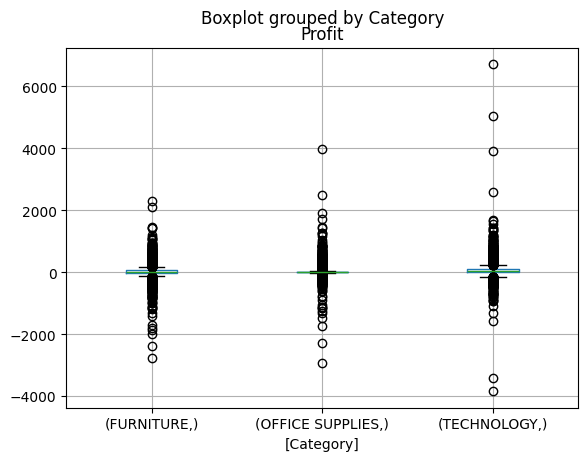

In [24]:
# let's create a boxplot of profit by category

df.boxplot(column = ["Profit"], by = ["Category"])

<a id='describe'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="describe"></a>

#### Get descriptive statistics


Descriptive statistic are summary statistics that quantitatively describes or summarizes features from a collection of information or dataset. This typically included things like sample size, measures of central tendency (mean, median, mode), measures of variability or dispersion (standard deviation, min, max, kurtosis, skewness)
    

**<code>[.describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)</code>** will return descriptive statistics for all quantitative columns of a DataFrame

<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_describe.png">

<code>df.describe()</code>

For each numerical column the following descriptive statistics are provided:
* count
* mean
* standard deviation
* minimum
* 25, 50 & 75th percentiles
* max </div>


In [25]:
# try out describe on our df

df.describe()

,Category (OLD),Quantity,Discount,Profit,Postal Code,Shipping Cost,10/1/2014,7/1/2014,11/1/2014,9/1/2014,1/1/2014,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014
count,0.0,17531.000000,17531.000000,17531.000000,3321.000000,17531.000000,1626.000000,1087.000000,2147.000000,2018.000000,918.000000,2153.000000,1675.000000,1284.000000,1068.000000,1051.000000,756.000000,1748.000000
mean,NaN,3.457989,0.143291,28.758540,56192.587775,26.268085,260.004077,237.999706,258.630194,238.432727,262.819777,233.694238,272.608921,224.611407,246.349038,230.991305,244.493857,229.870745
std,NaN,2.290856,0.211830,174.283412,31977.397359,56.545260,543.523703,433.300176,520.039000,463.761215,528.201441,432.184769,502.542821,396.292046,593.698325,442.449941,399.022820,423.420032
min,NaN,1.000000,0.000000,-3839.990400,1841.000000,0.010000,0.990000,1.080000,1.197000,1.359000,2.040000,1.161000,1.584000,1.188000,0.556000,1.188000,1.788000,0.444000
25%,NaN,2.000000,0.000000,0.000000,28110.000000,2.570000,31.491000,27.225000,30.840000,26.793000,27.412500,30.360000,36.984000,30.105000,32.202000,28.545000,35.460000,29.467500
50%,NaN,3.000000,0.000000,9.200000,60440.000000,7.720000,87.940000,78.327000,90.936000,79.620000,83.912400,79.120000,99.870000,79.425000,83.788800,79.140000,93.765000,79.960000
75%,NaN,5.000000,0.200000,36.808500,90032.000000,24.455000,267.678000,244.147500,269.190000,244.085000,263.491500,232.880000,284.043000,226.730000,246.533625,234.338000,275.121000,239.477925
max,NaN,14.000000,0.800000,6719.980800,99301.000000,867.690000,11199.968000,4001.040000,10499.970000,7958.580000,5443.960000,4864.320000,5211.120000,4298.850000,13999.960000,4799.984000,3425.400000,5486.670000


<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="other"></a>

#### Other built in summary statistic functions

Pandas also provides a large set of summary functions that can operate on different kinds of pandas objects (DataFrame columns, series, groupby etc.)

* **<code>[.count()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.count.html?highlight=count#pandas.DataFrame.count)</code>**    
* **<code>[.sum()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sum.html?highlight=sum#pandas.DataFrame.sum)</code>**
* **<code>[.min()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.min.html?highlight=min#pandas.DataFrame.min)</code>**
* **<code>[.max()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.max.html?highlight=max#pandas.DataFrame.max)</code>**
* **<code>[.mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.mean.html?highlight=mean#pandas.DataFrame.mean)</code>**
* **<code>[.median()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.median.html?highlight=median#pandas.DataFrame.median)</code>**
* **<code>[.var()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.var.html?highlight=var#pandas.DataFrame.var)</code>**
* **<code>[.std()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.std.html?highlight=std#pandas.DataFrame.std)</code>**
    
These functions become especially useful in the next section where there might be some specific selection of  data you want to analyze </div>


In [26]:
# here we get the mean discount for the entire column

df["Discount"].mean()

np.float64(0.14329119844846275)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:**

1) What is the **maximum** value in the Shipping Cost column?
</div>

In [27]:
### Your code here

##### <mark> Solution

In [28]:

df["Shipping Cost"].max()

867.69

<a id='dataselection'></a>

---
<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Data Selection, Slicing & Dicing
    
### Basic data selection & filtering
* <a href='#column_selection'>column selection</a>
* <a href='#loc'>select data by labels/names</a>
* <a href='#iloc'>select data by integer index/position</a>
   
### Advanced data selection
* <a href='#conditionalselection'>select data for a given condition or threshold</a>
* <a href='#conditionalselectionandreturn'>return subset of data for a given condition or threshold</a>
* <a href='#multicondition'>select data based on multiple conditions
or thresholds</a>

### Note
* <a href='#view_vs_copy'>'view' of data vs a copy</a>    

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="column_selection"></a>

#### Column Selection

**[column selection](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html#how-do-i-select-specific-columns-from-a-dataframe)**
    
<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_select_columns.png">

To view a single single column:
* <code>df['column_name']</code>
  * returns a pandas Series object, which is similar to a 1D array or list

~ OR ~
* <code>df[['column_name']]</code>
  * returns a DataFrame

Multiple columns:
* <code>df[['column_1', 'column_2']]</code></div>


In [29]:
# get the Category column as a pd.series

df["Category"]

,Category
Row ID,
IN-2014-23218,FURNITURE
IN-2014-24599,FURNITURE
IN-2014-24597,FURNITURE
IN-2014-27993,FURNITURE
IN-2014-28967,FURNITURE
...,...
ZA-2014-49187,TECHNOLOGY
ZI-2014-42069,TECHNOLOGY
ZI-2014-43712,TECHNOLOGY


In [30]:
type(df["Category"])

pandas.core.series.Series

In [31]:
# get the Category and Customer ID columns as a dataframe

df[["Category", "Customer ID"]]

,Category,Customer ID
Row ID,,
IN-2014-23218,FURNITURE,AA-10375
IN-2014-24599,FURNITURE,CA-12055
IN-2014-24597,FURNITURE,CA-12055
IN-2014-27993,FURNITURE,GM-14455
IN-2014-28967,FURNITURE,VB-21745
...,...,...
ZA-2014-49187,TECHNOLOGY,TS-11205
ZI-2014-42069,TECHNOLOGY,BS-1380
ZI-2014-43712,TECHNOLOGY,JB-6045


In [32]:
type(df[["Category", "Customer ID"]])

pandas.core.frame.DataFrame

<a id='view_vs_copy'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="loc"></a>

#### Select rows or columns using labels

**<code>[.loc()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html)</code>** allows access to a group of rows and columns by label(s) or a boolean array.

**select rows:**
* <code>df.loc['index']</code>
    * Hint: similar to column selection described above, for row selection using `df.loc[ ]` returns a Series where `df.loc[[ ]]` returns a DataFrame


**select row and column:**
* <code>df.loc['index', 'column']</code> </div>


In [33]:
# get rows where the index is IN-2014-28967

df.loc["IN-2014-28967"]

,IN-2014-28967
Order ID,IN-2014-47337
Segment,Corporate
Category,FURNITURE
Category (OLD),NaN
Sub-Category,CHAIRS
Product Name,"Hon Rocking Chair, Red"
Product ID,FUR-CH-10003965
Country,Afghanistan
Market,APAC
Region,Central Asia


In [34]:
df.loc[["IN-2014-28967"]]

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
IN-2014-28967,IN-2014-47337,Corporate,FURNITURE,NaN,CHAIRS,"Hon Rocking Chair, Red",FUR-CH-10003965,Afghanistan,APAC,Central Asia,...,914.34,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[ACME Co, Buy n Large, Dunder Mifflin, LexCorp..."


In [35]:
# get index:ZI-2014-48372 and column "Country"

df.loc["ZI-2014-48372", "Country"]

'Zimbabwe'

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="iloc"></a>

#### Select rows and columns by position
    
**[.iloc()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html)** allows positional selection: row number, column number

(Note: the same slicing notation that we saw with `numpy` arrays works with `iloc`.)
    
Example: <code>df.iloc([row(s) number, column(s) number])</code>

Examples:
* Select all rows and all columns
    * <code>df.iloc[:,:]</code>
* Select first 5 rows and all columns
    * <code>df.iloc[0:4, :]</code>
* Select all rows and last 5 columns
    * <code>.iloc[:,-5:]</code></div>


In [36]:
# get the first 9 rows and all columns

df.iloc[:9, :]

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
IN-2014-23218,IN-2014-75456,Consumer,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Door Stop, Erganomic",FUR-FU-10004064,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Globex Corp, Hudsucker Indust..."
IN-2014-24599,IN-2014-29767,Home Office,FURNITURE,NaN,BOOKCASES,"Ikea Library with Doors, Mobile",FUR-BO-10001255,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,731.82,NaN,NaN,NaN,Herat,Hirat,"[ACME Co, Buy n Large, Dunder Mifflin, Globex ..."
IN-2014-24597,IN-2014-29767,Home Office,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Door Stop, Erganomic",FUR-FU-10004064,Afghanistan,APAC,Central Asia,...,NaN,NaN,NaN,169.68,NaN,NaN,NaN,Herat,Hirat,"[Dunder Mifflin, LexCorp, Olivander Crafts, Ro..."
IN-2014-27993,IN-2014-20415,Home Office,FURNITURE,NaN,BOOKCASES,"Bush Classic Bookcase, Pine",FUR-BO-10002204,Afghanistan,APAC,Central Asia,...,NaN,2070.15,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Olivander Crafts]"
IN-2014-28967,IN-2014-47337,Corporate,FURNITURE,NaN,CHAIRS,"Hon Rocking Chair, Red",FUR-CH-10003965,Afghanistan,APAC,Central Asia,...,914.34,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[ACME Co, Buy n Large, Dunder Mifflin, LexCorp..."
AG-2014-50986,AG-2014-2760,Consumer,FURNITURE,NaN,FURNISHINGS,"Deflect-O Light Bulb, Erganomic",FUR-DEF-10002865,Algeria,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,17.61,Saida,Saida,"[ACME Co, Hudsucker Industries, Wayne Enterpri..."
AG-2014-50983,AG-2014-2760,Consumer,FURNITURE,NaN,CHAIRS,"Novimex Rocking Chair, Black",FUR-NOV-10002453,Algeria,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,516.00,Saida,Saida,"[Dunder Mifflin, Umbrella Corporation]"
AG-2014-49384,AG-2014-2040,Consumer,FURNITURE,NaN,FURNISHINGS,"Rubbermaid Frame, Durable",FUR-RUB-10003004,Algeria,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Algiers,Alger,"[Buy n Large, Hudsucker Industries, LexCorp, R..."
AG-2014-47438,AG-2014-2600,Home Office,FURNITURE,NaN,BOOKCASES,"Ikea 3-Shelf Cabinet, Pine",FUR-IKE-10003642,Algeria,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Algiers,Alger,"[Buy n Large, Dunder Mifflin, Hudsucker Indust..."


In [37]:
# get all rows and last 4 columns

df.iloc[:, -4:]

,6/1/2014,City,State,manufacturers
Row ID,,,,
IN-2014-23218,NaN,Kabul,Kabul,"[Dunder Mifflin, Globex Corp, Hudsucker Indust..."
IN-2014-24599,NaN,Herat,Hirat,"[ACME Co, Buy n Large, Dunder Mifflin, Globex ..."
IN-2014-24597,NaN,Herat,Hirat,"[Dunder Mifflin, LexCorp, Olivander Crafts, Ro..."
IN-2014-27993,NaN,Kabul,Kabul,"[Dunder Mifflin, Olivander Crafts]"
IN-2014-28967,NaN,Kabul,Kabul,"[ACME Co, Buy n Large, Dunder Mifflin, LexCorp..."
...,...,...,...,...
ZA-2014-49187,NaN,Ndola,Copperbelt,"[ACME Co, Royco Waystar, Umbrella Corporation]"
ZI-2014-42069,NaN,Bulawayo,Bulawayo,[Dunder Mifflin]
ZI-2014-43712,77.688,Bulawayo,Bulawayo,"[ACME Co, Buy n Large, Hudsucker Industries]"


<a id='conditionalselection'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="conditionalselection"></a>

#### Advanced data selection

#### Select data given a specific threshold or condition

You can conditionally select data using **[.loc[ ]](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html)** or **[.query()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html)** or directly on the DataFrame. Each of these utilize boolean masking.
     
<code>.loc</code>
* <code>df.loc[df['column'] > 7]</code>
* <code>df.loc[df['column'] == 'string']</code>
    * Pros: explicit, can be easier to read for those who already know python
    * Cons: more verbose than query
    
----
<code>.query()</code>:
This method uses boolean expressions and may be easier & more intuitive for those who know SQL or other database languages.

Examples:
* <code>df.query('column > 7')</code>
* <code>df.query('column == string')</code>
    * Pros: can be easier for those who know SQL or other database languages, less verbose
    * Cons: can be difficult for those that don't know SQL, doesn't handle column names that contain spaces very well   </div>


In [38]:
# use .loc to select where Profit > 500

df.loc[df["Profit"] > 500]

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
IN-2014-27993,IN-2014-20415,Home Office,FURNITURE,NaN,BOOKCASES,"Bush Classic Bookcase, Pine",FUR-BO-10002204,Afghanistan,APAC,Central Asia,...,NaN,2070.15,NaN,NaN,NaN,NaN,NaN,Kabul,Kabul,"[Dunder Mifflin, Olivander Crafts]"
AO-2014-44396,AO-2014-2270,Consumer,FURNITURE,NaN,TABLES,"Chromcraft Round Table, Adjustable Height",FUR-CHR-10002278,Angola,Africa,Africa,...,NaN,NaN,1877.16,NaN,NaN,NaN,NaN,Luanda,Luanda,"[Dunder Mifflin, Globex Corp, LexCorp, Royco W..."
IN-2014-24624,IN-2014-23880,Consumer,FURNITURE,NaN,BOOKCASES,"Sauder Classic Bookcase, Traditional",FUR-BO-10004852,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,NaN,NaN,3139.128,Mandurah,Western Australia,"[Buy n Large, Globex Corp, LexCorp, Umbrella C..."
IN-2014-31153,IN-2014-80286,Consumer,FURNITURE,NaN,CHAIRS,"Harbour Creations Executive Leather Armchair, ...",FUR-CH-10000051,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wollongong,New South Wales,"[Globex Corp, LexCorp, Royco Waystar, Umbrella..."
ID-2014-21496,ID-2014-35892,Consumer,FURNITURE,NaN,CHAIRS,"SAFCO Executive Leather Armchair, Set of Two",FUR-CH-10003597,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Brisbane,Queensland,"[ACME Co, Buy n Large, Dunder Mifflin, Globex ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CA-2014-33921,CA-2014-127180,Home Office,TECHNOLOGY,NaN,PHONES,Polycom CX600 IP Phone VoIP phone,TEC-PH-10001494,United States,US,East,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York City,New York,"[Buy n Large, Dunder Mifflin, Hudsucker Indust..."
CA-2014-33920,CA-2014-127180,Home Office,TECHNOLOGY,NaN,COPIERS,Canon imageCLASS 2200 Advanced Copier,TEC-CO-10004722,United States,US,East,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York City,New York,[Globex Corp]
CA-2014-36178,CA-2014-143567,Corporate,TECHNOLOGY,NaN,ACCESSORIES,Logitech diNovo Edge Keyboard,TEC-AC-10004145,United States,US,South,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Henderson,Kentucky,"[Dunder Mifflin, Globex Corp, Hudsucker Indust..."


<a id='conditionalselectionandreturn'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="conditionalselectionandreturn"></a>

#### Return a subset of data given a specific threshold or condition

You can also return specific columns after doing conditional selection data using **[<code>.loc</code>](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html)**.
  
Single return column:
* <code>df.loc[df['selection_column'] > 7, 'return_column']</code>

Multiple return columns (provide columns as a list):
* <code>df.loc[df['selection_column'] > 7, ['return_column1', 'return_column2']]</code>
</div>


In [39]:
# get the Category and Sub-Category where profit is above 500

df.loc[df["Profit"] > 500, ["Category", "Sub-Category"]]

,Category,Sub-Category
Row ID,,
IN-2014-27993,FURNITURE,BOOKCASES
AO-2014-44396,FURNITURE,TABLES
IN-2014-24624,FURNITURE,BOOKCASES
IN-2014-31153,FURNITURE,CHAIRS
ID-2014-21496,FURNITURE,CHAIRS
...,...,...
CA-2014-33921,TECHNOLOGY,PHONES
CA-2014-33920,TECHNOLOGY,COPIERS
CA-2014-36178,TECHNOLOGY,ACCESSORIES


<a id='multicondition'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="multicondition"></a>

#### Multiple condition selection

You may wish to select rows or columns where multiple conditions are met. You can combine conditions with <code>.loc</code> in `numpy` and utilize <code>&</code> and <code>|</code>

Example:
<code>df.loc[(df['column1'] == 'string') & (df['column2'] > threshold)]</code>

</div>


In [40]:
# return all entries where Profit is greater than 900 and the Sub-Category is "Bookcases"
# the & means both conditions must be met

df.loc[(df["Sub-Category"] == "BOOKCASES") & (df["Profit"] > 900)]

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
IN-2014-24624,IN-2014-23880,Consumer,FURNITURE,NaN,BOOKCASES,"Sauder Classic Bookcase, Traditional",FUR-BO-10004852,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,NaN,NaN,3139.128,Mandurah,Western Australia,"[Buy n Large, Globex Corp, LexCorp, Umbrella C..."
IN-2014-21263,IN-2014-56206,Consumer,FURNITURE,NaN,BOOKCASES,"Sauder Classic Bookcase, Metal",FUR-BO-10001471,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,NaN,NaN,5486.670,Sydney,New South Wales,"[ACME Co, Buy n Large, Hudsucker Industries, U..."
IN-2014-24037,IN-2014-17930,Consumer,FURNITURE,NaN,BOOKCASES,"Sauder Classic Bookcase, Metal",FUR-BO-10001471,China,APAC,North Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Qingdao,Shandong,"[ACME Co, Globex Corp, Hudsucker Industries, O..."
IN-2014-28056,IN-2014-66573,Consumer,FURNITURE,NaN,BOOKCASES,"Bush Classic Bookcase, Mobile",FUR-BO-10004665,China,APAC,North Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Beijing,Beijing,"[ACME Co, Buy n Large, Olivander Crafts, Umbre..."
MX-2014-4452,MX-2014-157077,Consumer,FURNITURE,NaN,BOOKCASES,"Dania Classic Bookcase, Traditional",FUR-BO-10002300,Cuba,LATAM,Caribbean,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Camagüey,Camagüey,"[ACME Co, Buy n Large, Globex Corp, Royco Ways..."
IN-2014-25795,IN-2014-76016,Corporate,FURNITURE,NaN,BOOKCASES,"Sauder Classic Bookcase, Traditional",FUR-BO-10004852,India,APAC,Central Asia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thiruvananthapuram,Kerala,"[Buy n Large, Hudsucker Industries, Umbrella C..."
IT-2014-16653,IT-2014-4540740,Consumer,FURNITURE,NaN,BOOKCASES,"Safco Classic Bookcase, Metal",FUR-BO-10004999,Spain,EU,South,...,2188.05,NaN,NaN,NaN,NaN,NaN,NaN,Seville,Andalusía,"[Globex Corp, Hudsucker Industries, Olivander ..."
ES-2014-12449,ES-2014-4957212,Consumer,FURNITURE,NaN,BOOKCASES,"Bush Classic Bookcase, Pine",FUR-BO-10004709,United Kingdom,EU,North,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Burnley,England,"[Buy n Large, Globex Corp, LexCorp, Olivander ..."
ZA-2014-42448,ZA-2014-7540,Consumer,FURNITURE,NaN,BOOKCASES,"Ikea Library with Doors, Traditional",FUR-IKE-10002894,Zambia,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lusaka,Lusaka,"[ACME Co, Royco Waystar, Umbrella Corporation,..."


In [41]:
# return all entries where the Country is "Australia" or the Country is "Zambia"
# the | means at least one condition must be met

df.loc[(df["Country"] == "Australia") | (df["Country"] == "Zambia")]

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
ID-2014-25801,ID-2014-42388,Consumer,FURNITURE,NaN,FURNISHINGS,"Deflect-O Frame, Duo Pack",FUR-FU-10004780,Australia,APAC,Oceania,...,NaN,99.09,NaN,NaN,NaN,NaN,NaN,Wollongong,New South Wales,[Hudsucker Industries]
IN-2014-21802,IN-2014-25644,Consumer,FURNITURE,NaN,BOOKCASES,"Bush Corner Shelving, Metal",FUR-BO-10004230,Australia,APAC,Oceania,...,444.42,NaN,NaN,NaN,NaN,NaN,NaN,Tamworth,New South Wales,"[Hudsucker Industries, LexCorp]"
IN-2014-22521,IN-2014-10090,Consumer,FURNITURE,NaN,CHAIRS,"Harbour Creations Steel Folding Chair, Red",FUR-CH-10001204,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,88.101,NaN,NaN,Sydney,New South Wales,"[Buy n Large, Dunder Mifflin, Globex Corp, Oli..."
IN-2014-26860,IN-2014-64396,Home Office,FURNITURE,NaN,FURNISHINGS,"Deflect-O Stacking Tray, Black",FUR-FU-10001129,Australia,APAC,Oceania,...,NaN,NaN,NaN,NaN,NaN,NaN,91.26,Bundaberg,Queensland,"[ACME Co, Buy n Large, Dunder Mifflin, LexCorp..."
ID-2014-30742,ID-2014-84164,Home Office,FURNITURE,NaN,FURNISHINGS,"Tenex Photo Frame, Duo Pack",FUR-FU-10000507,Australia,APAC,Oceania,...,NaN,NaN,NaN,31.14,NaN,NaN,NaN,Cairns,Queensland,"[ACME Co, Dunder Mifflin, Olivander Crafts]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZA-2014-41769,ZA-2014-1370,Consumer,TECHNOLOGY,NaN,COPIERS,"Brother Personal Copier, Color",TEC-BRO-10003986,Zambia,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chingola,Copperbelt,"[ACME Co, Hudsucker Industries, Olivander Craf..."
ZA-2014-45397,ZA-2014-8330,Corporate,TECHNOLOGY,NaN,PHONES,"Cisco Headset, VoIP",TEC-CIS-10003439,Zambia,Africa,Africa,...,NaN,88.53,NaN,NaN,NaN,NaN,NaN,Lusaka,Lusaka,"[Buy n Large, Olivander Crafts, Umbrella Corpo..."
ZA-2014-50068,ZA-2014-6660,Home Office,TECHNOLOGY,NaN,COPIERS,"Brother Fax and Copier, High-Speed",TEC-BRO-10003401,Zambia,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,189.69,NaN,Lusaka,Lusaka,"[Buy n Large, LexCorp, Olivander Crafts, Umbre..."


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercises:**

1) Select Row ID "AG-2014-50983" and all columns

2) Get the mean profit when the Category is furniture
    
3) How many entries in the DataFrame are there where Profit is negative and Market is EU</div>


In [42]:
### Your code here

In [43]:
### Your code here

In [44]:
### Your code here

##### <mark> Solutions

In [45]:
# row id AG-2014-50983 and all cols

df.loc[["AG-2014-50983"]]

,Order ID,Segment,Category,Category (OLD),Sub-Category,Product Name,Product ID,Country,Market,Region,...,12/1/2014,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers
Row ID,,,,,,,,,,,,,,,,,,,,,
AG-2014-50983,AG-2014-2760,Consumer,FURNITURE,NaN,CHAIRS,"Novimex Rocking Chair, Black",FUR-NOV-10002453,Algeria,Africa,Africa,...,NaN,NaN,NaN,NaN,NaN,NaN,516.0,Saida,Saida,"[Dunder Mifflin, Umbrella Corporation]"


In [46]:
df.loc["AG-2014-50983"]

,AG-2014-50983
Order ID,AG-2014-2760
Segment,Consumer
Category,FURNITURE
Category (OLD),NaN
Sub-Category,CHAIRS
Product Name,"Novimex Rocking Chair, Black"
Product ID,FUR-NOV-10002453
Country,Algeria
Market,Africa
Region,Africa


In [47]:
df.loc["AG-2014-50983", :]

,AG-2014-50983
Order ID,AG-2014-2760
Segment,Consumer
Category,FURNITURE
Category (OLD),NaN
Sub-Category,CHAIRS
Product Name,"Novimex Rocking Chair, Black"
Product ID,FUR-NOV-10002453
Country,Algeria
Market,Africa
Region,Africa


In [48]:
# Mean profit when Category is Furniture
df.loc[df["Category"] == "FURNITURE", "Profit"].mean()

np.float64(26.68421359426352)

In [49]:
df.loc[df["Category"] == "FURNITURE", "Profit"]

,Profit
Row ID,
IN-2014-23218,39.840
IN-2014-24599,102.420
IN-2014-24597,79.680
IN-2014-27993,848.700
IN-2014-28967,356.580
...,...
ZA-2014-49186,16.800
ZI-2014-43446,-181.458
ZI-2014-42718,-109.038


In [50]:
# profit is negative and market is EU
len(df.loc[(df["Profit"] < 0) & (df["Market"] == "EU")])

768

<a id='manipulate'></a>

# Note
<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="view_vs_copy"></a>

#### Views vs copies

We often want to work with only a subset of a DataFrame. For that purpose, we can  select only those rows or columns that we need and leave the rest.
    
Building off of our knowledge of views vs copies that we learned with our numpy tutorial, when we subset an array the result is not always a new array; sometimes what numpy returns is a view of the data in the original array.
Since pandas Series and DataFrames are backed by numpy arrays, it will probably come as no surprise that something similar sometimes happens in pandas. Unfortunately, while this behavior is relatively straightforward in numpy, in pandas there’s just no getting around the fact that it’s a hot mess.
    
**The View/Copy Headache in pandas**: In numpy, the rules for when you get views and when you don’t are a little complicated, but they are consistent: certain behaviors (like simple indexing) will always return a view, and others (fancy indexing) will never return a view.

But in pandas, whether you get a view or not- and whether changes made to a view will propagate back to the original DataFrame- depends on the structure and data types in the original DataFrame
    
<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_view_vs_copy_b.png">  

    
**When to create a copy using <code>[.copy()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html)</code>**
      
**Creating copies** of DataFrame can be especially useful when doing exploratory analysis on a DataFrame where you want to keep the integrity of the original DataFrame in case you make a mistake.
    
<code>new_df = df.copy()</code> makes a copy (by creating a new object) of this object’s indices and data. By default modifications to the data or indices of the copy will not be reflected in the original object but see the documentation and the parameter [<code>deep</code>](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html) for more information
    
Note: Like all other variables, try to keep your DataFrame naming descriptive and intuitive to read! (For example "new_df" would be a bad name)


<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_copy_example_a.png" width='60%'>
<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_copy_example_b.png" width='60%'>

</div>


---
<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Data Manipulations
    
* <a href='#astype'> adjust column type</a>
* <a href='#addcolumns'> create new columns</a>
    * <a href='#apply'> `.apply()`</a>
* <a href='#dropcolumns'>drop unnecessary or redundant columns</a>
* <a href='#sort_values'>sort the whole dataframe based on one column's values</a>
    

</div>


<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="astype"></a>

#### Change column data type
    
After examining your DataFrame you may find that there are certain columns whose data types do not match your assumptions or whose data types could inhibit analysis. For example, if you have a column that contains numbers, but the data type is string - you would not actually be able to do numeric operations on it. You can cast the data to a different datatype using  **[.astype()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html)**.
    
To cast a column to a new data type:
<code>df['column_1'] = df['column_1'].astype(new type)</code>

Remember some of the possible datatypes are:
* int
* float64
* bool
* string
</div>

In [51]:
# we know that in our dataframe quantity should be an integer
# but right now it's a float

df["Quantity"]

,Quantity
Row ID,
IN-2014-23218,2.0
IN-2014-24599,2.0
IN-2014-24597,4.0
IN-2014-27993,5.0
IN-2014-28967,7.0
...,...
ZA-2014-49187,1.0
ZI-2014-42069,1.0
ZI-2014-43712,1.0


In [52]:
# let's change that using .astype()
# then we can check the type after

# change the type to an int
df["Quantity"] = df["Quantity"] .astype(int)

# check the data type
df["Quantity"]

,Quantity
Row ID,
IN-2014-23218,2
IN-2014-24599,2
IN-2014-24597,4
IN-2014-27993,5
IN-2014-28967,7
...,...
ZA-2014-49187,1
ZI-2014-42069,1
ZI-2014-43712,1


<a id='addcolumns'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="addcolumns"></a>

#### Add new columns
    
Frequently you'll want to add **[new columns](https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html)**. There are multiple ways to do this!

<img src="https://raw.githubusercontent.com/AllenInstitute/EducationAndEngagement/main/NeuroCodingWorkshop/support_files/images/pandas/pandas_make_new_columns.png">

To add already computed data:
* <code>df['new_column_name'] = already_computed_data</code>
    
You can also calculate new columns based on currently existing columns:
* <code>df['AB_SUM'] = df['A'] + df['B']</code>
* <code>df['Volume'] = df['Length'] * df['Height'] * df['Depth']</code>
    
Note: newly created columns are always added to the end of the DataFrame    
</div>


#####<mark> Solution

In [53]:
# let's create a "Profit Per Unit" column by diving profit by quantity

df['Profit Per Unit'] = df['Profit'] / df['Quantity']

In [54]:
# now let's view the results

df[["Profit", "Quantity", "Profit Per Unit"]]

,Profit,Quantity,Profit Per Unit
Row ID,,,
IN-2014-23218,39.840,2,19.920
IN-2014-24599,102.420,2,51.210
IN-2014-24597,79.680,4,19.920
IN-2014-27993,848.700,5,169.740
IN-2014-28967,356.580,7,50.940
...,...,...,...
ZA-2014-49187,19.710,1,19.710
ZI-2014-42069,-20.799,1,-20.799
ZI-2014-43712,-59.562,1,-59.562


<a id='apply'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="apply"></a>

#### .apply()
    
**[.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html)** is a fairly powerful tool that can do many things. In this context we will use it to create new columns using functions from other packages or functions you've created.

* <code>df['new_column_name'] = df[column(s) of interest].apply(function)</code>
    
* <code>df['A_sqrt'] = df['A'].apply(np.sqrt)</code>
* <code>df['A_adjusted'] = df['A'].apply(your_function)</code>
</div>

In [55]:
# let's create a function to fix the capitalization for strings in this column

df['Category']

,Category
Row ID,
IN-2014-23218,FURNITURE
IN-2014-24599,FURNITURE
IN-2014-24597,FURNITURE
IN-2014-27993,FURNITURE
IN-2014-28967,FURNITURE
...,...
ZA-2014-49187,TECHNOLOGY
ZI-2014-42069,TECHNOLOGY
ZI-2014-43712,TECHNOLOGY


In [56]:
# let's practice by making a function that will fix the capitalization of the
# "Category" column and then applying it

def capitalize_first_letter(string):
    all_lower = string.lower()
    cap_first = all_lower.capitalize()
    return cap_first

df["Category"] = df["Category"].apply(capitalize_first_letter)

# view the results
df[["Category"]]

,Category
Row ID,
IN-2014-23218,Furniture
IN-2014-24599,Furniture
IN-2014-24597,Furniture
IN-2014-27993,Furniture
IN-2014-28967,Furniture
...,...
ZA-2014-49187,Technology
ZI-2014-42069,Technology
ZI-2014-43712,Technology


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercises:**
    
1) In these code examples, what do you think the <code>axis</code> argument is doing?
What kind of output do you think will be returned? For each?


* <code>df[['A', 'B']].apply(np.mean, axis = 0)</code>
* <code>df[['A', 'B']].apply(np.mean, axis = 1)</code>
    
2) Which axis setting is the default? (hint- check the documentation)
</div>

In [57]:
### Your code here

##### <mark> Solutions

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html

axis{0 or ‘index’, 1 or ‘columns’}, default 0
Axis along which the function is applied:

0 or ‘index’: apply function to each column.

1 or ‘columns’: apply function to each row.

In [58]:
# test it out with a simple df

num_df = pd.DataFrame({
    "A": [10, 20, 30, 40],
    "B": [1, 2, 3, 4]
})
num_df

,A,B
0,10,1
1,20,2
2,30,3
3,40,4


In [59]:
# 1 value per column

num_df[['A', 'B']].apply(np.mean, axis = 0)

,0
A,25.0
B,2.5


In [60]:
# 1 value per row

num_df[['A', 'B']].apply(np.mean, axis = 1)

,0
0,5.5
1,11.0
2,16.5
3,22.0


<a id='apply'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="dropcolumns"></a>

#### Drop specific columns & rows using <code>.drop()</code>
    
You can easily drop rows or columns using **<code>[.drop()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)</code>**

There are many reasons you may wish to drop columns from your DataFrame. Here are a few examples:
* irrlevant to the analysis you are going to do
* out of date
* redundant information
* non-analyzable due to high rates of NaN or empty entries
    
Drop columns:    
* <code>df = df.drop(columns=['column1', 'columns2'])</code>
* <code>df = df.drop('column_name',axis=1)</code>

Drop rows:
* <code>df = df.drop(index=('index1_string, 'index2_string'))</code>   
* <code>df = df.drop([row, row])</code></div>


<a id='apply'></a>

In [61]:
# let's drop the 'Category (OLD)'column

df.drop(columns=["Category (OLD)"], inplace = True)

# check the results in the dataframe columns list
df.columns

Index(['Order ID', 'Segment', 'Category', 'Sub-Category', 'Product Name',
       'Product ID', 'Country', 'Market', 'Region', 'Quantity', 'Discount',
       'Profit', 'Customer ID', 'Customer Name', 'Order Priority',
       'Postal Code', 'Ship Mode', 'Shipping Cost', '10/1/2014', '7/1/2014',
       '11/1/2014', '9/1/2014', '1/1/2014', '12/1/2014', '8/1/2014',
       '5/1/2014', '3/1/2014', '4/1/2014', '2/1/2014', '6/1/2014', 'City',
       'State', 'manufacturers', 'Profit Per Unit'],
      dtype='object')

<a id='sort_values'></a>

<div style="padding: 5px; padding-left: 10px; background:#e6e6e6">
<a name="sort_values"></a>

#### Sort the DataFrame based on column values
    
**<code>[.sort_values()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)</code>** to sort your DataFrame by the the values of a particular column or columns.

<code>df.sort_values(by=['column1', 'column2'], ascending = boolean, inplace = boolean)</code>
    
Pro-tip: Sorting the values of your DataFrame before plotting creates more interpretable plots.
    

</div>


In [62]:
# let's sort our USA_df by 'Segment', 'Category' and 'Sub-Category'
# we will leave the underlying data unchanged by setting inplace to False

df.sort_values(by = ["Segment", "Category", "Sub-Category"], inplace = False)

,Order ID,Segment,Category,Sub-Category,Product Name,Product ID,Country,Market,Region,Quantity,...,8/1/2014,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers,Profit Per Unit
Row ID,,,,,,,,,,,,,,,,,,,,,
AG-2014-46003,AG-2014-8600,Consumer,Furniture,BOOKCASES,"Sauder Classic Bookcase, Pine",FUR-SAU-10002255,Algeria,Africa,Africa,2,...,NaN,NaN,NaN,NaN,NaN,NaN,Batna,Batna,"[ACME Co, Globex Corp, Umbrella Corporation]",74.3400
AO-2014-45199,AO-2014-9370,Consumer,Furniture,BOOKCASES,"Bush Classic Bookcase, Pine",FUR-BUS-10001243,Angola,Africa,Africa,2,...,NaN,828.06,NaN,NaN,NaN,NaN,Luanda,Luanda,"[ACME Co, Buy n Large, Globex Corp, Hudsucker ...",202.8600
US-2014-6344,US-2014-165512,Consumer,Furniture,BOOKCASES,"Bush Library with Doors, Metal",FUR-BO-10002968,Argentina,LATAM,South,2,...,NaN,NaN,291.0240,NaN,NaN,NaN,Buenos Aires,Buenos Aires,"[Dunder Mifflin, Globex Corp, Hudsucker Indust...",-58.2080
US-2014-1158,US-2014-107664,Consumer,Furniture,BOOKCASES,"Ikea Floating Shelf Set, Traditional",FUR-BO-10001585,Argentina,LATAM,South,4,...,NaN,NaN,NaN,NaN,NaN,NaN,La Plata,Provincia de Buenos Aires,"[Dunder Mifflin, Hudsucker Industries, Royco W...",-13.6440
IN-2014-21802,IN-2014-25644,Consumer,Furniture,BOOKCASES,"Bush Corner Shelving, Metal",FUR-BO-10004230,Australia,APAC,Oceania,4,...,NaN,NaN,NaN,NaN,NaN,NaN,Tamworth,New South Wales,"[Hudsucker Industries, LexCorp]",38.2650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US-2014-40156,US-2014-114356,Home Office,Technology,PHONES,Plantronics Encore H101 Dual Earpieces Headset,TEC-PH-10003171,United States,US,South,1,...,35.96,NaN,NaN,NaN,NaN,NaN,Charlotte,North Carolina,"[ACME Co, Buy n Large, LexCorp, Olivander Craf...",3.5960
US-2014-33227,US-2014-101539,Home Office,Technology,PHONES,Mitel MiVoice 5330e IP Phone,TEC-PH-10004165,United States,US,West,3,...,NaN,NaN,659.9760,NaN,NaN,NaN,Seattle,Washington,"[ACME Co, Royco Waystar, Umbrella Corporation,...",16.4994
CA-2014-36882,CA-2014-105333,Home Office,Technology,PHONES,Panasonic Business Telephones KX-T7736,TEC-PH-10001468,United States,US,East,3,...,NaN,NaN,NaN,NaN,NaN,NaN,New York City,New York,"[LexCorp, Umbrella Corporation, Wayne Enterpri...",54.6060


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:**

1) Sort the df by profit per unit
</div>


In [63]:
### Your code here

##### <mark> Solutions

In [64]:
df["Profit per Unit"] = df["Profit"] / df["Quantity"]
df_sorted = df.sort_values("Profit per Unit", ascending = False)
df_sorted

,Order ID,Segment,Category,Sub-Category,Product Name,Product ID,Country,Market,Region,Quantity,...,5/1/2014,3/1/2014,4/1/2014,2/1/2014,6/1/2014,City,State,manufacturers,Profit Per Unit,Profit per Unit
Row ID,,,,,,,,,,,,,,,,,,,,,
CA-2014-35487,CA-2014-166709,Consumer,Technology,COPIERS,Canon imageCLASS 2200 Advanced Copier,TEC-CO-10004722,United States,US,East,3,...,NaN,NaN,NaN,NaN,NaN,Newark,Delaware,"[Buy n Large, Dunder Mifflin, Globex Corp, Hud...",1679.9952,1679.9952
CA-2014-39450,CA-2014-140151,Consumer,Technology,COPIERS,Canon imageCLASS 2200 Advanced Copier,TEC-CO-10004722,United States,US,West,4,...,NaN,13999.96,NaN,NaN,NaN,Seattle,Washington,"[ACME Co, Royco Waystar]",1679.9952,1679.9952
CA-2014-33920,CA-2014-127180,Home Office,Technology,COPIERS,Canon imageCLASS 2200 Advanced Copier,TEC-CO-10004722,United States,US,East,4,...,NaN,NaN,NaN,NaN,NaN,New York City,New York,[Globex Corp],979.9972,979.9972
CA-2014-37817,CA-2014-138289,Consumer,Office supplies,BINDERS,GBC DocuBind P400 Electric Binding System,OFF-BI-10004995,United States,US,Central,4,...,NaN,NaN,NaN,NaN,NaN,Jackson,Michigan,"[Buy n Large, Hudsucker Industries, LexCorp, O...",626.0554,626.0554
SF-2014-48905,SF-2014-4490,Consumer,Furniture,TABLES,"Bevis Conference Table, Rectangular",FUR-BEV-10004805,South Africa,Africa,Africa,2,...,NaN,NaN,NaN,NaN,NaN,George,Western Cape,[Dunder Mifflin],442.2300,442.2300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CA-2014-36607,CA-2014-131254,Consumer,Office supplies,BINDERS,Fellowes PB500 Electric Punch Plastic Comb Bin...,OFF-BI-10003527,United States,US,Central,6,...,NaN,NaN,NaN,NaN,NaN,Houston,Texas,"[Buy n Large, LexCorp]",-381.2970,-381.2970
CA-2014-34143,CA-2014-152093,Home Office,Office supplies,BINDERS,Fellowes PB500 Electric Punch Plastic Comb Bin...,OFF-BI-10003527,United States,US,Central,3,...,NaN,NaN,NaN,NaN,NaN,Chicago,Illinois,"[Buy n Large, Dunder Mifflin, LexCorp]",-381.2970,-381.2970
US-2014-36288,US-2014-122714,Corporate,Office supplies,BINDERS,Ibico EPK-21 Electric Binding System,OFF-BI-10001120,United States,US,Central,5,...,NaN,NaN,NaN,NaN,NaN,Chicago,Illinois,[Umbrella Corporation],-585.8969,-585.8969


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Final Exercises: Putting It All Together**
    
1) How many rows and columns are in df, and what are the unique values in the Region column?

2) Select all rows where Region is West and Order Priority is Critical. How many orders match?

3) Create a new column Shipping Cost Per Unit (Shipping Cost ÷ Quantity). What's the average value across the dataset?

4) Using `.iloc`, select the first 10 rows and columns 3 through 5 (by position) of df. Then check `.columns` to confirm which columns those actually are.

5) Sort df by Profit (descending), drop the Postal Code column, and show the top 5 highest-profit orders with only Category, Sub-Category, and Profit.

</div>

##### <mark> Solutions

In [65]:
# Q1

print(df.shape)
df['Region'].unique()

(17531, 35)


array(['Central Asia', 'Africa', 'South', 'Oceania', 'Central', 'EMEA',
       'Caribbean', 'Southeast Asia', 'Canada', 'North Asia', 'North',
       'West', 'East'], dtype=object)

In [66]:
# Q2

critical_west = df.loc[(df['Region'] == 'West') & (df['Order Priority'] == 'Critical')]
len(critical_west)

68

In [67]:
# Q3

df['Shipping Cost Per Unit'] = df['Shipping Cost'] / df['Quantity']
df['Shipping Cost Per Unit'].mean()

np.float64(7.8151359787604635)

In [68]:
# Q4

df.iloc[:10, 2:5]
df.columns[2:5]

Index(['Category', 'Sub-Category', 'Product Name'], dtype='object')

In [69]:
# Q5

df_sorted = df.sort_values('Profit', ascending=False)
df_sorted.drop(columns=['Postal Code'])[['Category', 'Sub-Category', 'Profit']].head(5)

,Category,Sub-Category,Profit
Row ID,,,
CA-2014-39450,Technology,COPIERS,6719.9808
CA-2014-35487,Technology,COPIERS,5039.9856
ES-2014-12069,Office supplies,APPLIANCES,3979.0800
CA-2014-33920,Technology,COPIERS,3919.9888
MO-2014-50788,Technology,COPIERS,2597.2800
